# MARL Notebook

### Using Jax for speedy reinforcement learning

Motivation: After developing our environment and training schedule, we ran into time and compute constraints
- Could not run more than ~40 envs on our computer, which for many timesteps took hours

Solution: Use Jax (via MuJoCo Playground environments) to speed things up
- Run in Google collab to get around Jax GPU OS constraints (Jax GPU is meant to run on Linux)

### Background

Jax compiles Python code into optimized machine code (usually via XLA)
- Traces Python functions, builds computation graph, generates machine code for device (GPU in this case)
- Jax can then reuse compiled code, which (combined with GPU speed), makes computations very fast

Since Jax/JIT traces operations and builds a computation graph, we want to keep things relatively simple to avoid long computations
- Created a new Crazyflie XMl without all the collision geoms to speed things up
  - Previously, the physics integrator had to consider all collisions even if we never actually collided with anything
  - We weren't using these geoms anyway, as we end training episodes if drone(s) get to close to the ground or one another ("crash" but no collision)

### Resources

[MuJoCo Playground](https://github.com/google-deepmind/mujoco_playground) with example [Cartpole Balance RL Notebook](https://colab.research.google.com/github/google-deepmind/mujoco_playground/blob/main/learning/notebooks/dm_control_suite.ipynb)


In [2]:
#@title Install pre-requisites
!pip install mujoco
!pip install mujoco_mjx
!pip install brax
!pip install playground

# Rendering video
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 736.5/736.5 kB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.1/344.1 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.7 MB/s eta 0:00:00


In [3]:
# @title Check if MuJoCo installation was successful

import distutils.util
import os
import subprocess

if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.'
  )

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco

  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".'
  )

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl
Checking that the installation succeeded:
Installation successful.


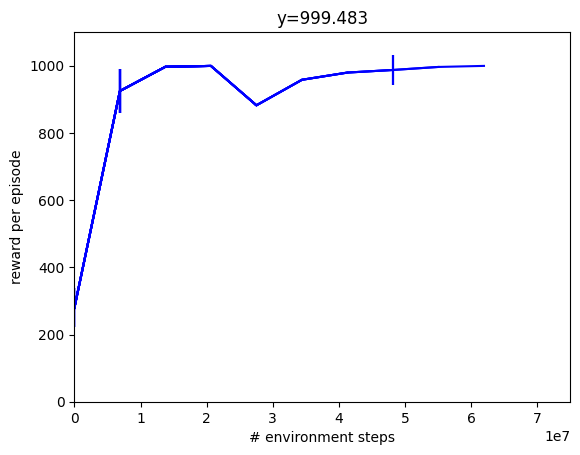

time to jit: 0:00:34.642567
time to train: 0:11:15.133317


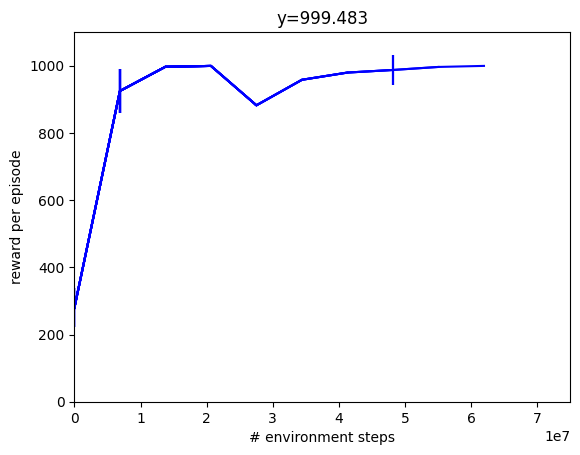

In [ ]:
# @title Cartpole Balance Example


from mujoco_playground import registry
import os

from datetime import datetime
import functools
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import mediapy as media
import jax
import jax.numpy as jnp
import numpy as np
from ml_collections import config_dict

from mujoco_playground import wrapper
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from mujoco_playground.config import dm_control_suite_params

print(jax.devices())

env = registry.load('CartpoleBalance')
ppo_params = dm_control_suite_params.brax_ppo_config('CartpoleBalance')

x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.ylim([0, 1100])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())


ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **ppo_params.network_factory
  )

train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress
)


make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [ ]:
# @title Cartpole Balance Visualization
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

env_cfg = registry.get_default_config('CartpoleBalance')
rng = jax.random.PRNGKey(42)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(env_cfg.episode_length):
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

render_every = 1
frames = env.render(rollout[::render_every])
rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt / render_every)

100%|██████████| 1001/1001 [00:03<00:00, 315.07it/s]


This browser does not support the video tag.


In [5]:
# @title Crazyflie Env
from mujoco_playground._src import mjx_env
import mujoco
from mujoco import mjx
import jax
import jax.numpy as jnp
import numpy as np
from ml_collections import config_dict

import mediapy as media
from typing import Any


# Helper function to convert drone quaternion to rotation matrix
def quat_to_rotation_matrix(q):
    """q is [w, x, y, z]"""
    w, x, y, z = q
    return jnp.array([
        [1 - 2*(y**2 + z**2), 2*(x*y - z*w),     2*(x*z + y*w)],
        [2*(x*y + z*w),       1 - 2*(x**2 + z**2), 2*(y*z - x*w)],
        [2*(x*z - y*w),       2*(y*z + x*w),     1 - 2*(x**2 + y**2)]
    ])


# Importing Scene from Google Drive (mounted folder)
# Using simplified models without collisions to reduce Jax graph computations
# Don't use collisions anyway, env terminates if drone is near ground
SCENE_PATH = "/content/drive/MyDrive/assets_mjx/bitcraze_crazyflie_2/scene.xml"

# Basic config
BASE_HOVER_THRUST = 0.26487
TARGET_POS = jnp.array([0.0, 0.0, 0.5])
NUM_DRONES = 1
DRONE_SPACING_ALONG_AXIS = 0.4
QPOS_PER_DRONE = 7  # x,y,z + quat (4)
QVEL_PER_DRONE = 6  # linear (3) + angular (3)

# Random starting state sampled from distribution
TRAINING_POS_RANGE = 2.0
TRAINING_QUAT_RANGE = np.pi / 8
TRAINING_VEL_RANGE = 0.2
TRAINING_ANG_VEL_RANGE = 0.1

# Terminate if N distance further from target compared to starting distance
OUT_OF_BOUNDS_RANGE = 2.0

# Reward and observation constants
TERMINATION_PENALTY = -1.0
SURVIVAL_STEP_BONUS = -1.0 * TERMINATION_PENALTY / 1000
N_PREV_ACTIONS = 5

class CrazyflieEnv(mjx_env.MjxEnv):
    """Simple MJX environment using the Crazyflie drone model."""

    def __init__(self):
        # Define environment configuration (control and sim time steps)
        cfg = config_dict.ConfigDict()
        cfg.ctrl_dt = 0.02    # control step (50Hz)
        cfg.sim_dt = 0.002    # simulation step (500Hz)
        super().__init__(cfg)

        # Load MuJoCo model and convert to MJX
        self._mj_model = mujoco.MjModel.from_xml_path(SCENE_PATH)
        self._mjx_model = mjx.put_model(self._mj_model)

        # Define control/action size as number of actuators
        self._action_size = self._mj_model.nu

        # Obs size (just qpos and qvel for now)
        self._observation_size = self._mj_model.nq + self._mj_model.nv

        # If using multiple drones, arrange them in a line (along X axis for now)
        self.dir_x, self.dir_y = 1.0, 0.0
        self.drone_offsets = jnp.linspace(-(NUM_DRONES - 1) / 2, (NUM_DRONES - 1) / 2, NUM_DRONES) * DRONE_SPACING_ALONG_AXIS

    # Expected env properties for Brax PPO training
    @property
    def xml_path(self) -> str:
        return SCENE_PATH

    @property
    def action_size(self) -> int:
        return self.mjx_model.nu

    @property
    def mj_model(self) -> mujoco.MjModel:
        return self._mj_model

    @property
    def mjx_model(self) -> mjx.Model:
        return self._mjx_model


    def reset(self, rng: jax.Array) -> mjx_env.State:
        """Vectorized reset for Crazyflie drones."""

        # Random keys
        rng, rng_pos, rng_quat, rng_vel, rng_ang = jax.random.split(rng, 5)

        # Random positions
        std_pos = TRAINING_POS_RANGE / 2.0
        pos_noise = jax.random.normal(rng_pos, (NUM_DRONES, 3)) * std_pos
        start_pos = TARGET_POS + pos_noise
        start_pos = start_pos.at[:, 2].set(jnp.clip(start_pos[:, 2], 0.1, jnp.inf))

        # Drone offset along drones starting axis
        offset_xy = jnp.stack([
            self.drone_offsets * self.dir_x,
            self.drone_offsets * self.dir_y,
            jnp.zeros_like(self.drone_offsets)
        ], axis=1)
        start_pos += offset_xy

        # Random quaternions
        std_angle = TRAINING_QUAT_RANGE / 2.0
        axes = jax.random.normal(rng_quat, (NUM_DRONES, 3))
        axes = axes / jnp.linalg.norm(axes, axis=1, keepdims=True)
        angles = jax.random.normal(rng_quat, (NUM_DRONES,)) * std_angle
        w = jnp.cos(angles)
        quats = jnp.concatenate([w[:, None], axes * jnp.sin(angles)[:, None]], axis=1)

        # Linear and angular velocities
        lin_vel = (TRAINING_VEL_RANGE / 2.0) * jax.random.normal(rng_vel, (NUM_DRONES, 3))
        ang_vel = (TRAINING_ANG_VEL_RANGE / 2.0) * jax.random.normal(rng_ang, (NUM_DRONES, 3))

        # Assemble qpos/qvel in batch
        qpos = jnp.zeros((NUM_DRONES, QPOS_PER_DRONE), dtype=jnp.float32)
        qpos = qpos.at[:, 0:3].set(start_pos)
        qpos = qpos.at[:, 3:7].set(quats)
        qpos = qpos.reshape(-1)  # flatten for mjx_env

        qvel = jnp.zeros((NUM_DRONES, QVEL_PER_DRONE), dtype=jnp.float32)
        qvel = qvel.at[:, 0:3].set(lin_vel)
        qvel = qvel.at[:, 3:6].set(ang_vel)
        qvel = qvel.reshape(-1)  # flatten for mjx_env

        # Initialize state
        action_history = jnp.zeros((N_PREV_ACTIONS * self._action_size,))
        initial_distance_to_target = jnp.linalg.norm(start_pos[0] - TARGET_POS)

        data = mjx_env.init(self._mjx_model, qpos=qpos, qvel=qvel)

        metrics = {
            "reward/distance_improvement": jnp.zeros(()),
            "reward/proximity_bonus": jnp.zeros(()),
            "reward/survival_bonus": jnp.zeros(()),
            "reward/termination": jnp.zeros(()),
        }

        # Start prev action as hovering
        info = {
            "rng": rng,
            "initial_distance": initial_distance_to_target,
            "prev_pos": qpos[:3],
            "action_history": action_history
        }

        reward, done = jnp.zeros(2)
        obs = self._get_obs(data, info)

        return mjx_env.State(data=data, obs=obs, reward=reward, done=done, metrics=metrics, info=info)


    def step(self, state: mjx_env.State, action: jax.Array) -> mjx_env.State:
        """Vectorized Crazyflie step."""

        data = mjx_env.step(self._mjx_model, state.data, action, n_substeps=self.n_substeps)

        # Get observation
        obs = self._get_obs(data, state.info)

        pos = data.qpos[:3]

        ##############
        # Rewards
        ##############

        pos_error = TARGET_POS - pos
        distance_to_target = jnp.linalg.norm(pos_error)

        # Compute previous position (stored in state.info, for example)
        prev_pos = state.info.get("prev_pos", pos)
        distance_to_target_old = jnp.linalg.norm(TARGET_POS - prev_pos)
        distance_improvement = distance_to_target_old - distance_to_target

        # Proximity bonus to target
        proximity_bonus = 0.01 * (1 - jnp.tanh(distance_to_target))

        # Combine total reward
        reward = SURVIVAL_STEP_BONUS + distance_improvement + proximity_bonus


        ###############
        # State update
        ###############

        # Done condition: Much further from target compared to start or too close to ground
        current_distance_to_target = jnp.linalg.norm(pos - TARGET_POS)
        done = (
            (pos[2] < 0.05) |
            (current_distance_to_target > state.info["initial_distance"] + OUT_OF_BOUNDS_RANGE)
        ).astype(jnp.float32)

        # Add termination penalty if done
        reward += done * TERMINATION_PENALTY

        # Update action history
        prev_action_history = state.info["action_history"]
        new_action_history = jnp.concatenate([prev_action_history[4:], action])

        state.metrics["reward/distance_improvement"] = distance_improvement
        state.metrics["reward/proximity_bonus"] = proximity_bonus
        state.metrics["reward/survival_bonus"] = SURVIVAL_STEP_BONUS
        state.metrics["reward/termination"] = done * TERMINATION_PENALTY

        state.info["prev_pos"] = pos
        state.info["action_history"] = new_action_history

        return mjx_env.State(data=data, obs=obs, reward=reward, done=done, metrics=state.metrics, info=state.info)



    def _get_obs(self, data: mjx.Data, info: dict[str, Any]):
        # qpos and qvel are 1D for single drone
        qpos = data.qpos  # shape (QPOS_PER_DRONE,)
        qvel = data.qvel  # shape (QVEL_PER_DRONE,)

        # Quaternion [w, x, y, z] represented as rotation matrix (3, 3)
        quat = qpos[3:7]
        rotation_matrix = quat_to_rotation_matrix(quat)
        rotation_matrix_flat = rotation_matrix.reshape(-1)

        # Relative position to target in drone body frame
        pos = qpos[:3]
        pos_error = TARGET_POS - pos
        relative_pos_body = rotation_matrix.T @ pos_error  # shape (3,)

        # Convert linear velocity to body frame
        linear_vel = qvel[:3]
        linear_vel_body = rotation_matrix.T @ linear_vel

        ang_vel = qvel[3:6]

        # Concatenate features into observation
        obs = jnp.concatenate([
            rotation_matrix_flat,
            relative_pos_body,
            linear_vel_body,
            ang_vel,
            info["action_history"],
        ])
        return obs


# Rollout example
def run_rollout():
    env = CrazyflieEnv()
    jit_env_reset = jax.jit(env.reset)
    jit_env_step = jax.jit(env.step)

    key = jax.random.PRNGKey(0)
    state = jit_env_reset(key)
    rollout = [state]

    episode_length = 1000

    print("Crazyflie Test Rollout")
    print("Starting pos:", np.asarray(state.info["prev_pos"]))
    print(f"Initial obs shape: {state.obs.shape}")
    print("=" * 60)

    for i in range(episode_length):
        # Simple hover with tiny random noise
        key, subkey = jax.random.split(key)
        hover_offset = jax.random.uniform(subkey, (), minval=-0.002, maxval=0.002)
        action = jnp.array([0.26487 + hover_offset, 0.0, 0.0, 0.0])

        # Step the environment
        state = jit_env_step(state, action)
        rollout.append(state)

        # Convert JAX arrays to NumPy for readable printing
        metrics_np = jax.tree_util.tree_map(
            lambda x: np.asarray(x).item() if np.size(x) == 1 else np.asarray(x),
            state.metrics
        )
        ctrl_np = np.asarray(action)
        prev_pos_np = np.asarray(state.info.get("prev_pos", np.zeros(3)))

        # Parse Obs
        obs_np = np.asarray(state.obs)
        rel_pos = obs_np[0:3]
        lin_vel = obs_np[3:6]
        ang_vel = obs_np[6:9]
        prev_action = obs_np[9:13]

        # Print every 10 steps
        if i % 10 == 0:
            print(f"\n\nStep {i:04d}, Action {ctrl_np}, Reward {float(state.reward):+.4f}")
            print(f"  \nReward breakdown")
            print(f"    Dist Improvement: {metrics_np.get('reward/distance_improvement', np.nan):+.4f}")
            print(f"    Proximity Bonus: {metrics_np.get('reward/proximity_bonus', np.nan):+.4f}")
            print(f"    Survival Bonus: {metrics_np.get('reward/survival_bonus', np.nan):+.4f}")
            print(f"    Termination: {metrics_np.get('reward/termination', np.nan):+.4f}")

            print(f"  \nObservation breakdwon")
            print(f"    Relative pos (body): {rel_pos}")
            print(f"    Linear vel (body):   {lin_vel}")
            print(f"    Angular vel:         {ang_vel}")
            print(f"    Prev action:         {prev_action}")

        # Terminate if done
        if bool(state.done):
            print(f"\nEnvironment terminated at step {i} (done=True)")
            break

    # Utility to render target as geom in scene
    print("\nRendering trajectory...")
    target_geom_id = mujoco.mj_name2id(env.mj_model, mujoco.mjtObj.mjOBJ_GEOM, b"target")

    def move_target_geom(scene: mujoco.MjvScene, target_pos: np.ndarray):
        scene.geoms[target_geom_id].pos[:] = target_pos

    modify_target_fn = lambda scene: move_target_geom(scene, TARGET_POS)

    # Collect frames, use track camera from xml scene and update geom pos to target pos
    frames = env.render(
        rollout,
        camera="track",
        modify_scene_fns=[modify_target_fn] * len(rollout),
    )
    media.show_video(frames, fps=1.0 / env.dt)

    # Summary
    rewards = [float(s.reward) for s in rollout]
    print(f"\nTotal steps: {len(rewards)}, Final reward: {rewards[-1]:.4f}")

run_rollout()

Crazyflie Test Rollout
Starting pos: [-2.4424558  -2.0356805   0.70554423]
Initial obs shape: (38,)


Step 0000, Action [0.26289916 0.         0.         0.        ], Reward +0.0007
  
Reward breakdown
    Dist Improvement: -0.0003
    Proximity Bonus: +0.0000
    Survival Bonus: +0.0010
    Termination: +0.0000
  
Observation breakdwon
    Relative pos (body): [0.9306616  0.16523613 0.32644454]
    Linear vel (body):   [-0.04458884  0.9367849  -0.34705314]
    Angular vel:         [-0.36315402  0.30843326  0.8791974 ]
    Prev action:         [ 2.2586987   2.245784   -0.092217   -0.05054317]


Step 0010, Action [0.26366338 0.         0.         0.        ], Reward +0.0019
  
Reward breakdown
    Dist Improvement: +0.0009
    Proximity Bonus: +0.0000
    Survival Bonus: +0.0010
    Termination: +0.0000
  
Observation breakdwon
    Relative pos (body): [0.9264452  0.17388754 0.33386   ]
    Linear vel (body):   [-0.05463237  0.93963253 -0.33779576]
    Angular vel:         [-0.37244418 

100%|██████████| 65/65 [00:00<00:00, 202.39it/s]


This browser does not support the video tag.



Total steps: 65, Final reward: -1.0675


In [6]:
# @title Crazyflie Training Setup

from datetime import datetime
import functools
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import mediapy as media
import jax
import jax.numpy as jnp
import numpy as np
from ml_collections import config_dict

from mujoco_playground import wrapper
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from mujoco_playground.config import dm_control_suite_params


# Progress plots
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]
def progress(num_steps, metrics):
    clear_output(wait=True)
    times.append(datetime.now())
    x_data.append(num_steps)
    y_data.append(metrics["eval/episode_reward"])
    y_dataerr.append(metrics["eval/episode_reward_std"])

    plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
    plt.ylim([-50, 50])
    plt.xlabel("# environment steps")
    plt.ylabel("reward per episode")
    plt.title(f"y={y_data[-1]:.3f}")
    plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")
    display(plt.gcf())


# PPO training parameters
ppo_params = config_dict.create(
    num_timesteps=60_000_000,
    num_evals=10,
    reward_scaling=10.0,
    episode_length=1500,
    normalize_observations=True,
    action_repeat=1,
    unroll_length=30,
    num_minibatches=32,
    num_updates_per_batch=16,
    discounting=0.995,
    learning_rate=3e-4,
    entropy_cost=1e-2,
    num_envs=2048,
    batch_size=1024,
)

ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
    del ppo_training_params["network_factory"]
    network_factory = functools.partial(
        ppo_networks.make_ppo_networks,
        **ppo_params.network_factory
    )

train_fn = functools.partial(
    ppo.train,
    **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress
)

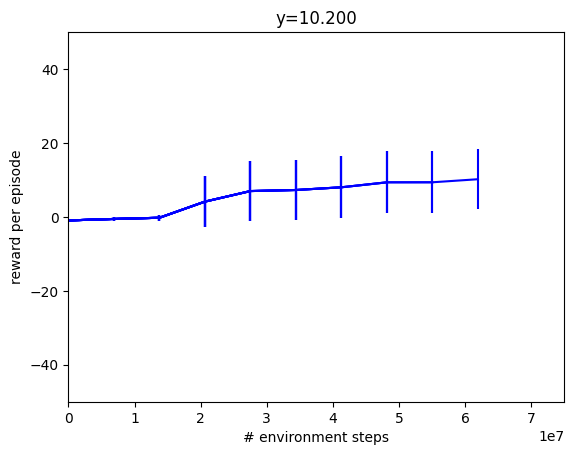

time to jit: 0:01:04.499230
time to train: 0:18:13.000057


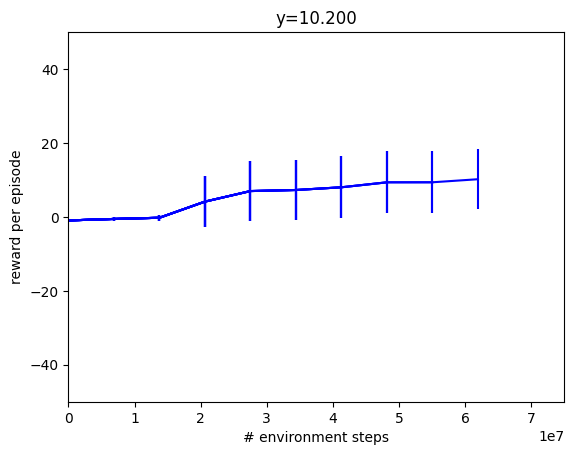

In [7]:
# @title Crazyflie Training

# # Jax logs
# import os
# os.environ["XLA_FLAGS"] = "--xla_dump_to=/tmp/xla_dump --xla_hlo_profile"
# jax.config.update("jax_debug_nans", True)       # detect NaNs
# jax.config.update("jax_log_compiles", True)     # log every JIT compilation
# jax.config.update("jax_disable_jit", False)    # ensure JIT is active

# Create environment
env = CrazyflieEnv()

# Train PPO agent - make_inference_fn is our policy function, params are network parameters, metrics are training stats
# Wrap env for training to match Brax format (e.g. add device and env dimensions to obs)
make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [8]:
#@title Crazyflie Evaluation

jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

rng = jax.random.PRNGKey(42)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(ppo_params["episode_length"]):
    if bool(state.done):
        break
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

    # Logs
    metrics_np = jax.tree_util.tree_map(lambda x: np.asarray(x).item() if np.size(x) == 1 else np.asarray(x), state.metrics)
    ctrl_np = np.asarray(ctrl)
    prev_pos_np = np.asarray(state.info.get("prev_pos", np.zeros(3)))

    # Print progress every 50 steps
    if i % 50 == 0:
        print(f"\nStep {i:04d}: Action {ctrl_np}")
        print(
            f"Rewards: | "
            f"Dist Improvement: {metrics_np.get('reward/distance_improvement', np.nan):.4f} | "
            f"Proximity Bonus: {metrics_np.get('reward/proximity_bonus', np.nan):.4f} | "
            f"Survival Bonus: {metrics_np.get('reward/survival_bonus', np.nan):.4f} | "
        )
        print(f"Prev Pos: {prev_pos_np}")


# Utility to render target as geom in scene based on env target pos
target_geom_id = mujoco.mj_name2id(env.mj_model, mujoco.mjtObj.mjOBJ_GEOM, b"target")
def move_target_geom(scene: mujoco.MjvScene, target_pos: np.ndarray):
    scene.geoms[target_geom_id].pos[:] = target_pos

modify_target_fn = lambda scene: move_target_geom(scene, TARGET_POS)
frames = env.render(rollout, camera="track", modify_scene_fns=[lambda scene: move_target_geom(scene, TARGET_POS)]*len(rollout))

rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt)


Step 0000: Action [0.88585496 0.7303829  0.955702   0.34075892]
Rewards: | Dist Improvement: 0.0014 | Proximity Bonus: 0.0021 | Survival Bonus: 0.0010 | 
Prev Pos: [0.6053803  0.79615563 0.09735034]

Step 0050: Action [ 0.21210693 -0.0537834  -0.49953344  0.0139023 ]
Rewards: | Dist Improvement: 0.0003 | Proximity Bonus: 0.0027 | Survival Bonus: 0.0010 | 
Prev Pos: [0.8426533  0.37226135 0.5059617 ]

Step 0100: Action [ 0.2178152  -0.195253   -0.24316525  0.12089934]
Rewards: | Dist Improvement: 0.0080 | Proximity Bonus: 0.0036 | Survival Bonus: 0.0010 | 
Prev Pos: [ 0.74103427 -0.04698234  0.6064372 ]

Step 0150: Action [0.12675662 0.05244467 0.22746666 0.0345356 ]
Rewards: | Dist Improvement: 0.0098 | Proximity Bonus: 0.0077 | Survival Bonus: 0.0010 | 
Prev Pos: [ 0.21237192 -0.0990007   0.5350445 ]

Step 0200: Action [0.33137834 0.05213117 0.12119342 0.00858443]
Rewards: | Dist Improvement: -0.0019 | Proximity Bonus: 0.0091 | Survival Bonus: 0.0010 | 
Prev Pos: [-0.09234836 -0.0149

100%|██████████| 1501/1501 [00:06<00:00, 221.85it/s]


This browser does not support the video tag.
